In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

annual_earnings_by_education_attainment = pd.read_csv('MedianEducationalEarnings.csv', encoding='latin-1')
annual_earnings_by_education_attainment

,"Sex, race/ethnicity, and educational attainment",2005,2005.1,2010,2010.1,2012,2012.1,2013,2013.1,2014,...,2018.1,2019,2019.1,2020,2020.1,2021,2021.1,2022,2022.1,2022.2
0,"Median annual earnings, all education levels","$48,990",-582,"$50,290",-433,"$49,670",-665,"$50,790",-204,"$49,740",...,-763,"$53,950",-427,"$57,510",-226,"$55,440",-245,"$54,210",NaN,"-1,073"
1,Less than high school completion,"32,130",-442,"29,330",-428,"29,480",-859,"30,580","-1,095","30,720",...,"-1,721","35,020",-640,"35,270",-685,"35,330","-2,331","35,470",NaN,-975
2,High school completion\1\,"41,530",-644,"41,460",-299,"39,350",-298,"38,830",-327,"38,560",...,-440,"41,280",-416,"42,140",-641,"43,970",-336,"41,790",NaN,-254
3,"Some college, no degree","47,640",-321,"44,030","-1,103","42,130","-1,203","44,020","-1,115","40,080",...,-460,"45,540","-1,017","46,110",-427,"44,980",-381,"45,230",NaN,"-1,135"
4,Associate's degree,"52,530","-1,113","50,190","-1,201","46,970",-735,"47,620","-2,470","44,740",...,-502,"47,350",-511,"50,620","-1,560","49,370",-931,"49,470",NaN,"-1,089"
5,Bachelor's or higher degree,"66,940","-1,320","66,850",-963,"64,990",-352,"64,930",-394,"64,760",...,"-1,240","69,500",-512,"70,310",-457,"71,650",-638,"71,060",NaN,-428
6,Bachelor's degree,"62,340",-435,"62,290",-574,"60,340",-877,"62,000","-1,445","62,690",...,-550,"64,880",-622,"68,470",-565,"67,320",-776,"66,610",NaN,-788
7,Master's or higher degree,"77,090",-736,"75,320","-1,115","77,200","-1,346","76,660",-743,"74,410",...,"-1,169","81,660","-1,339","79,720","-1,391","81,460","-1,834","80,180",NaN,"-1,318"
8,"Percent, all education levels\2\",70.8,-0.36,64.8,-0.42,67.2,-0.43,67.8,-0.5,70.2,...,-0.4,74.5,-0.39,65.7,-0.45,72.3,-0.4,75.8,NaN,-0.39
9,Less than high school completion,64.1,-1.29,48.1,-1.44,52.6,-1.32,55.9,-1.65,59.1,...,-1.78,65,-2.09,49.1,-1.98,53,-2.17,63.8,NaN,-2.44


In [ ]:
# Removes \1\ and \1\ from first column
annual_earnings_by_education_attainment['Sex, race/ethnicity, and educational attainment'] = annual_earnings_by_education_attainment['Sex, race/ethnicity, and educational attainment']
annual_earnings_by_education_attainment['Sex, race/ethnicity, and educational attainment'] = annual_earnings_by_education_attainment['Sex, race/ethnicity, and educational attainment'].str.replace('\\2\\', '', regex=False)
annual_earnings_by_education_attainment['Sex, race/ethnicity, and educational attainment'] = annual_earnings_by_education_attainment['Sex, race/ethnicity, and educational attainment'].str.replace('\\1\\', '', regex=False)

# Fills NaNs with 0
annual_earnings_by_education_attainment = annual_earnings_by_education_attainment.fillna(0)

# Drop unnecessary row (Random excel empty column)
if '2022.2' in annual_earnings_by_education_attainment.columns:
  annual_earnings_by_education_attainment['2022.1'] = annual_earnings_by_education_attainment['2022.2']
  annual_earnings_by_education_attainment = annual_earnings_by_education_attainment.drop('2022.2', axis=1)

# Get rid of minuses for std error
# List of columns
std_error_cols = ['2005.1', '2010.1', '2012.1', '2013.1', '2018.1', '2019.1', '2020.1', '2021.1', '2022.1']
yearly_earnings_cols = ['2005', '2010', '2012', '2013', '2018', '2019', '2020', '2021', '2022']
education_levels_col = 'Sex, race/ethnicity, and educational attainment'

# Use replace to with regex True to indiscriminately target any minus
annual_earnings_by_education_attainment[std_error_cols] = annual_earnings_by_education_attainment[std_error_cols].replace('-', '', regex=True)

# Converts every column entry into an integer for proper plotting
for col in annual_earnings_by_education_attainment:
  # If the column is the single string column, skip it
  if col == education_levels_col:
    continue
  # Replace any bad characters explicitly as string to avoid error
  annual_earnings_by_education_attainment[col] = (
        annual_earnings_by_education_attainment[col]
        .astype(str)
        .str.replace('$', '', regex=False)
        .str.replace(',', '', regex=False)
        .str.replace('-', '', regex=False)
        .str.strip()
    )
  # Make the entries into int type
  annual_earnings_by_education_attainment[col] = pd.to_numeric(annual_earnings_by_education_attainment[col])

# Separate accuracy scores and earnings scores for more clarity
yearly_accuracy_scores = annual_earnings_by_education_attainment[std_error_cols]
yearly_earnings = annual_earnings_by_education_attainment[yearly_earnings_cols].iloc[:8]

# Percentage portion of dataframe
yearly_earnings_as_percent = annual_earnings_by_education_attainment.iloc[8:, 1:]

# Show current tables
annual_earnings_by_education_attainment
yearly_accuracy_scores
yearly_earnings


,2005,2010,2012,2013,2018,2019,2020,2021,2022
0,48990.0,50290.0,49670.0,50790.0,52410.0,53950.0,57510.0,55440.0,54210.0
1,32130.0,29330.0,29480.0,30580.0,33430.0,35020.0,35270.0,35330.0,35470.0
2,41530.0,41460.0,39350.0,38830.0,41510.0,41280.0,42140.0,43970.0,41790.0
3,47640.0,44030.0,42130.0,44020.0,43040.0,45540.0,46110.0,44980.0,45230.0
4,52530.0,50190.0,46970.0,47620.0,47640.0,47350.0,50620.0,49370.0,49470.0
5,66940.0,66850.0,64990.0,64930.0,68400.0,69500.0,70310.0,71650.0,71060.0
6,62340.0,62290.0,60340.0,62000.0,64870.0,64880.0,68470.0,67320.0,66610.0
7,77090.0,75320.0,77200.0,76660.0,76580.0,81660.0,79720.0,81460.0,80180.0


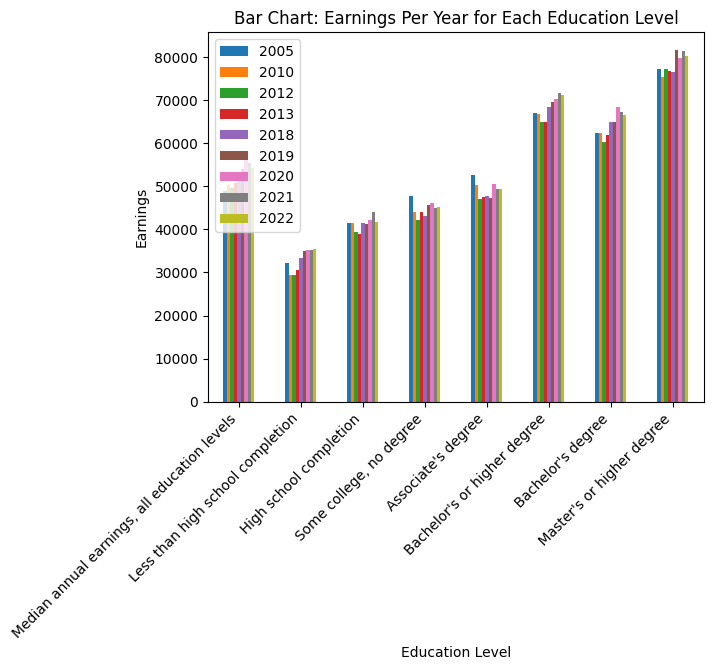

In [ ]:
# Bar plot:
# The question at its root is simple: Do earnings increase with education level?
# The data shows that it does! There is a clear increase at each level and the years make a
# clear positive slope with Bachelor's or higher swapped with Bachelor's. For the individual years,
# this positive slope remains consistent as well. Demonstrating a positive correlation between
# earnings and education level.

annual_earnings_by_education_attainment.iloc[:8].set_index('Sex, race/ethnicity, and educational attainment')[yearly_earnings_cols].plot(kind='bar', xlabel="Education Level", ylabel='Earnings')
plt.title('Bar Chart: Earnings Per Year for Each Education Level')

# Have labels rotated and set right end of ticks as center to make the plot look cleaner
plt.xticks(rotation=45, ha= 'right')
plt.show()

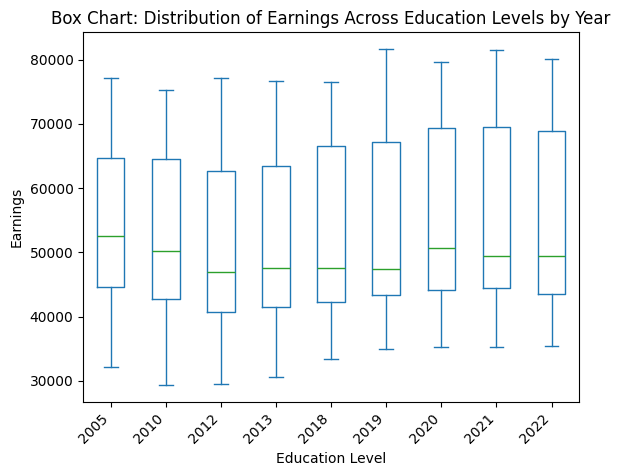

In [ ]:
# Box plot
# This plot further demonstrates the earnings gap becoming wider with inflation. The top whiskers represent the highest levels of
# education and vice vera. There is a clear trend of the boxes becoming wider as time passes, showing an increased level of variance
# which shows that the inequality continues to grow between education levels, further supporting the positive correlation.
annual_earnings_by_education_attainment.iloc[1:8].set_index('Sex, race/ethnicity, and educational attainment')[yearly_earnings_cols].plot(kind='box', xlabel="Education Level", ylabel='Earnings')
plt.title('Box Chart: Distribution of Earnings Across Education Levels by Year')

plt.xticks(rotation=45, ha= 'right')
plt.show()

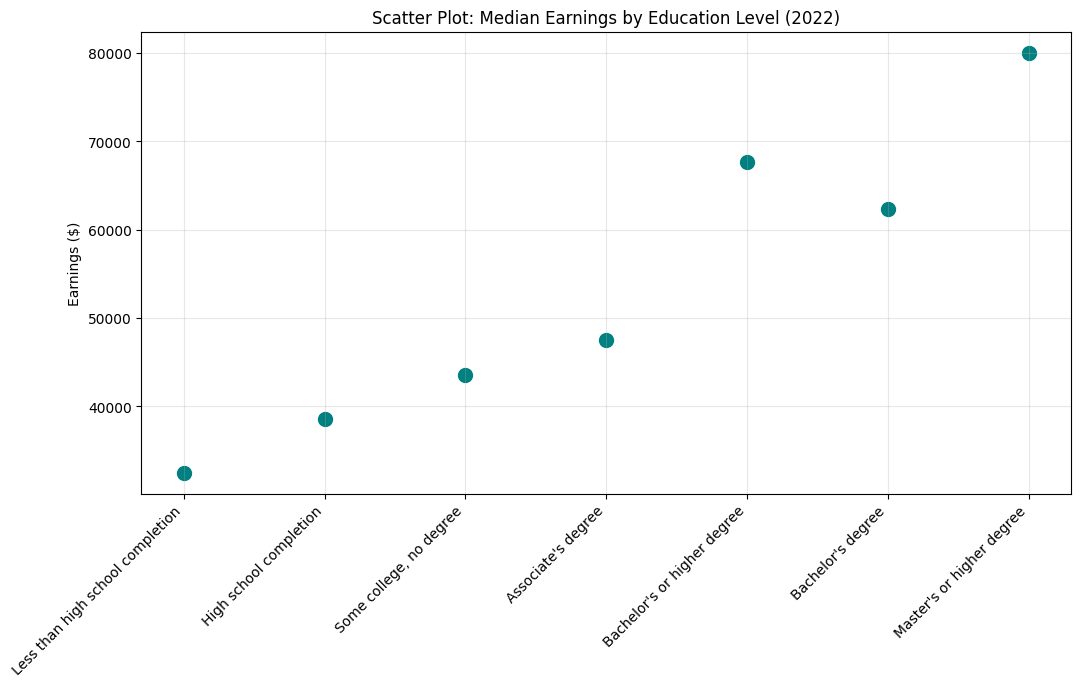

In [ ]:
import seaborn as sns
# Scatter Plot
scatter_df = annual_earnings_by_education_attainment.iloc[1:8].copy()
plt.figure(figsize=(12, 6))

# range creates a list of ints from 0 to len. This is needed to turn the qualitative labels into numbers that matplotlib can use
plt.scatter(range(len(scatter_df)), scatter_df['2017'], s=100, color='teal')

# Place actual row labels on plot in place of placeholder ints
plt.xticks(ticks=range(len(scatter_df)), labels=scatter_df['Sex, race/ethnicity, and educational attainment'], rotation=45, ha='right')

plt.title('Scatter Plot: Median Earnings by Education Level (2022)')
plt.ylabel('Earnings ($)')
plt.grid(True, alpha=0.3)
plt.show()

# Conclusions: This visualization only uses a single year for the purpose of demonstration, but I have checked each of the other years,
# and the conclusions remain the same, with each year showing the same trend with little difference. This further supports the positive
# correlation between education level and earnings.

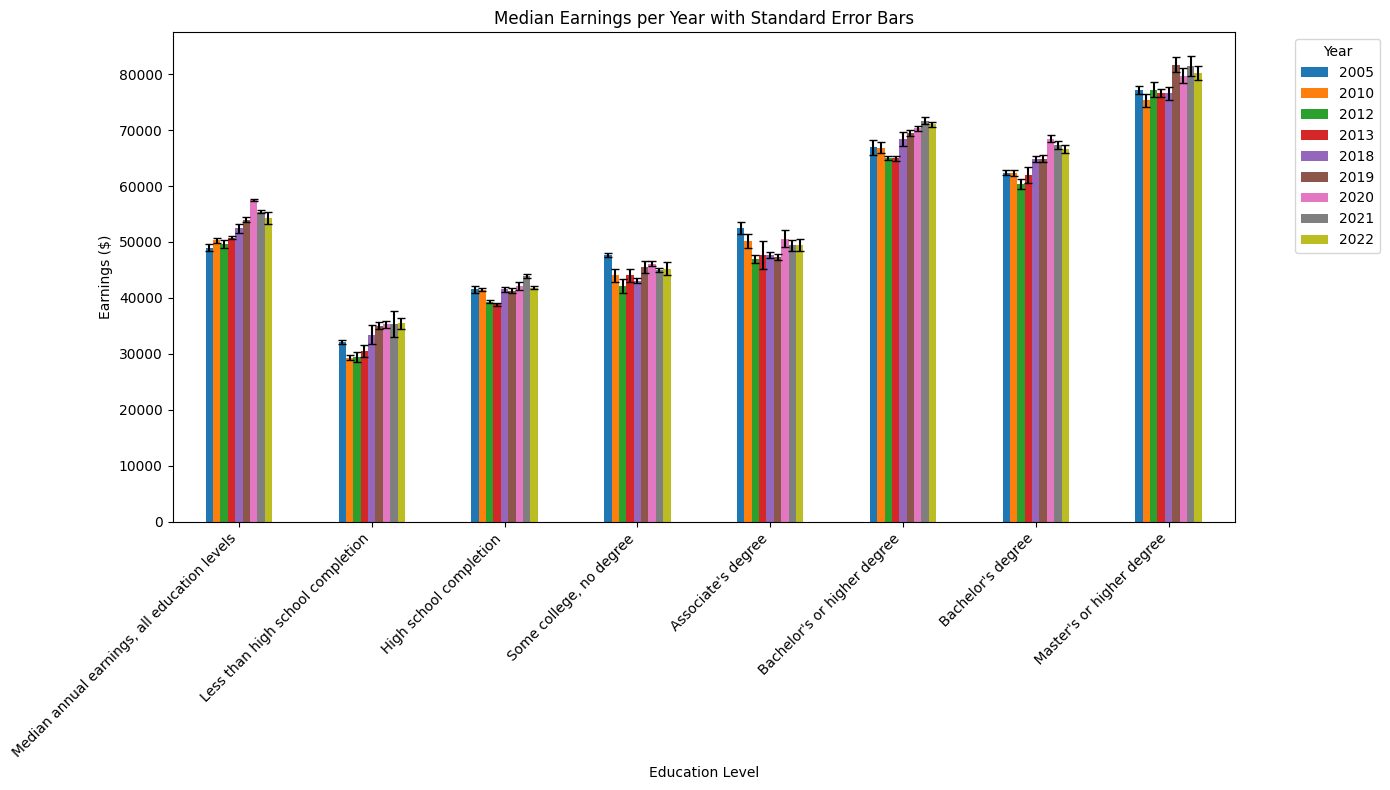

In [ ]:
# Error bars
# Simple subset of original df (All rows before percents)
subset = annual_earnings_by_education_attainment.iloc[:8].set_index('Sex, race/ethnicity, and educational attainment')

# Create new df with a subset containing the yearly cols only
earnings_data = subset[yearly_earnings_cols]

# Make a copy of the error columns and equalize column names to plot data
error_values = subset[std_error_cols].copy()
error_values.columns = yearly_earnings_cols

# Pass the error_values dataframe to the yerr argument
# yerr adds whiskers, capsize adds horizontal bar to whiskers, figsize changes width and height
earnings_data.plot(kind='bar', yerr=error_values, capsize=3, figsize=(14, 8), xlabel="Education Level", ylabel='Earnings ($)'
)

# Make title, format ticks
plt.title('Median Earnings per Year with Standard Error Bars')
plt.xticks(rotation=45, ha='right')
plt.legend(title="Year", bbox_to_anchor=(1.05, 1), loc='upper left') # bbox_to_anchor= and loc adjust legend position
plt.tight_layout() # Ensures no overlap of elements
plt.show()

# Conclusions: The data further reinforces the previously established positive correlation between median inc and education level.
# If you were to extend or shorten each bar to the max/min length based on the std error, the trend clearly remains consistent. For
# example, the highest std error whisker for 'less than high school completion' is not within the range of the lowest bar for
# 'high school completion', and this trend is largely consistent.

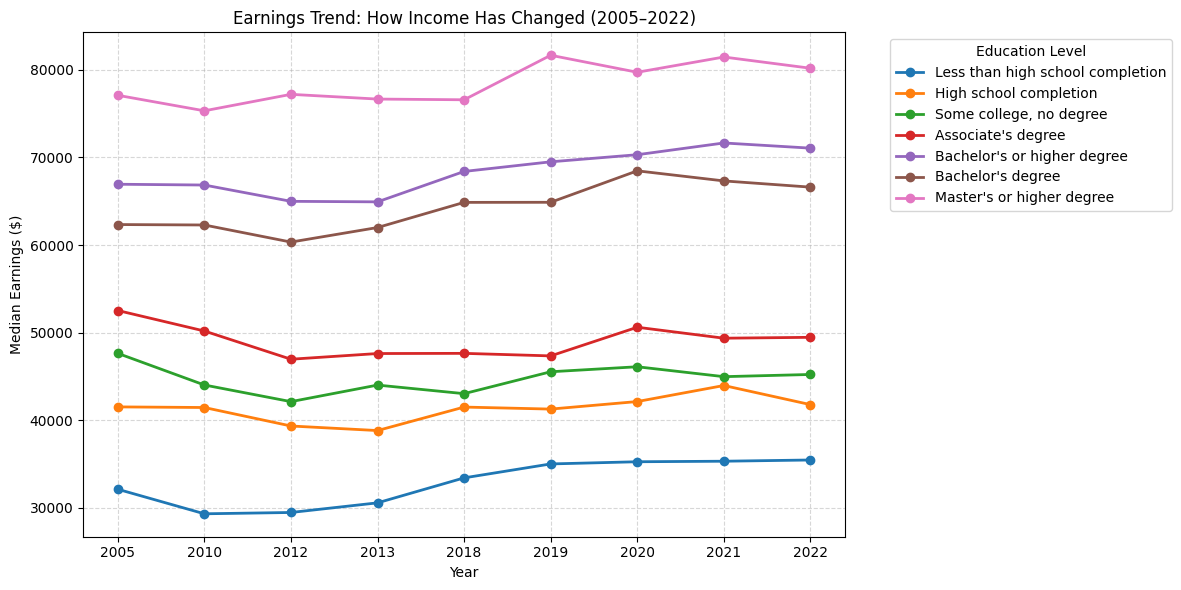

In [ ]:
# Line chart
line_df = annual_earnings_by_education_attainment.iloc[1:8].set_index('Sex, race/ethnicity, and educational attainment')[yearly_earnings_cols]

# Use transpose to flip the table to make years the rows (x-axis) and Degrees columns (the lines)
line_df_flipped = line_df.transpose()

line_df_flipped.plot(kind='line', marker='o', figsize=(12, 6), linewidth=2)

# Formatting polish
plt.title('Earnings Trend: How Income Has Changed (2005–2022)')
plt.xlabel('Year')
plt.ylabel('Median Earnings ($)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Education Level', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

# Conclusion: The line chart demonstrates the stability of the hierarchy established previously, as the lines representing the
# different education levels never intersect at any point, further strengthening the positive correlation between edu. level and earnings.
# There is also a noticeable higher increase in Bachelors and higher compared to the bottom four education levels, demonstrating growing
# variance.